## Data analysis activity: revisiting Galton's height study

### Summary and goals

We will study Galton's original data with $M$ rows. each row contains the height of one child and their two parents. Families can have more than one child, so the height of parents will appear repeated once per child of the family. Hence there will be the heights of $M_p$ fathers, $M_p$ mothers and $M$ children, with $M_p<M$. Such heigths are  denoted as $\{h^{(j)}_\text{father}\}_{j=1,\dots,M}$, $\{h^{(j)}_\text{mother}\}_{j=1,\dots,M}$ and $\{h^{(j)}_c\}_{j=1,\dots,M}$. The gender of children is also provided in the data, so we can distinguish between the heights of daughters and sons ($h_\text{son}$ and $h_\text{daughter}$ respectively ). The goal of this activity is to redo Galton’s analysis of such data. This is, we will try to rediscover his findings and examine how robust they are. First, we will measure the regression-to-the-mean relation:

$$
y_c \approx  \frac{2}{3} y_p,
$$

where $c$ refers to children and $p$ to parents, and where we define the deviation variables as:

$$
y_i = h_i - \hat{\mu}_i;\quad i = c,p
$$

with $h$ being height and $\hat{\mu}$ being the empirical mean height of the reference groups (children and parents). Thus, rather than analyzing absolute heights, we analyze their deviations from the mean. 

The second part of the exercise is to examine the asymmetry of conditional probabilities:

$$
P(\text{child extreme} \mid \text{parent extreme}) \neq
P(\text{parent extreme} \mid \text{child extreme})
$$

showing that conditioned probabilities are not symmetric. Here we use "parent extreme" and "child extreme" loosely, they are properly defined below.

---
### Preliminaries
Familiarize yourself with the data. Open it with pandas, try the basic commands of the tutorial.

0. Download and open the data with pandas. (See Hints section below).
1. Do you understand the information content of columns and rows?
2. Compute the total number of children ($M$) and the number of distinct parents ($M_p$). Do you understand the difference between $M$ and $M_p$?
3. Compute the mean height of fathers, mothers, children, sons and daughters, noted respectively $\mu_\text{father}$, $\mu_\text{mother}$, $\mu_c$, $\mu_\text{son}$, and $\mu_\text{daughter}$. Compute the ratio $k =\frac{\mu_\text{father}}{\mu_\text{mother}}$. Print the computed values. (See Hints section below).
4. Compute the standard deviation of the height of fathers, mothers, children, sons and daughters, denoted respectively $\sigma_\text{father}$, $\sigma_\text{mother}$,  $\sigma_c$, $\sigma_\text{son}$ and $\sigma_\text{daughter}$. Print the computed values. (See Hints section below).
5. Compute the mid-parent height $h_p = \frac{1}{2} \left(h_\text{mother} + h_\text{father}\right)$, add it as a new column of the dataframe. Compute the mean and standard deviation of the mid-parent height, denoted $\mu_p$ and $\sigma_p$.
6. Compute the deviates of both parents and children,   $y_i = h_i - \hat{\mu}_i;\quad i = c,p$.
7. Make a scatter plot of the parents deviates $y_p$. (See Hints section below).
8. Make another plot of the children deviates $y_c$.
9. Make a third scatter plot of $y_c$ on the y-axis and $y_p$ on the x-axis.
10. Make a plot containing two histograms for $y_p$ and $y_c$. Play with transparencies and colors. The plot should display a legend.
11. Compute Pearson's correlation between $y_p$ and $y_c$. (See Hints section below).

---

### Regression to the mean

The devil is in the details. Each child has two parents' height (mother and father), which one should we use? An average? Fathers and mothers have different average heights, is it fair to simply average them? We will compute $y_p$ in four different ways and compare results.

1. **Using the mid-parent height.**
   This is the naive approach of using the quantity computed in step 6 of the previous section. Using both  $y_p $ and $y_c$ compute a linear fit $y_c = a + b y_p$ . Is the value of a close to 0? Is the value of b close to 2/3? (See Hints section below to see how to do the linear fit with numpy).

2. **Applying Galton’s sex-correction factor of 1.08 for all female heights**  
   Galton applied this factor to remove sex-based systematic differences in height, effectively transforming female heights into *male-equivalent* heights. Galton used a conversion factor of $k = 1.08$. Is it similar to the value of $k$ you found in point 3 of the previous section? Hence, instead of using mothers' and daughters' hights, we convert them using  $\tilde{h}_\text{daughter} = 1.08 h_\text{daughter}$, and $\tilde{h}_\text{mother} = 1.08 h_\text{mother}$. Repeat the analysis of point 1 above using these new heights for females.

3. **Using deviation scores.**
   Through this perspective, we *standardize* deviations: we look for the "2/3" law using a different quantity $z$ which statisticians argue makes the 1.08 factor unnecessary:
   $$
   z_c \approx \frac{2}{3}  z_p,
   $$
   where
   $$
   z_c (child) =
   \begin{cases}
   \dfrac{h_c-\hat\mu_\text{son}}{\hat\sigma_\text{son}} & \text{if the child is a son},\\[2ex]
   \dfrac{h_c-\hat\mu_\text{daughter}}{\hat\sigma_\text{daughter}} & \text{if the child is a daughter}.
   \end{cases}
   $$
   and
   $$
   z_p =\frac{1}{2} \left(\frac{h_\text{mother}-\hat{\mu}_\text{mother}}{\hat{\sigma}_\text{mother}}+ \frac{h_\text{father}-\hat{\mu}_\text{father}}{\hat{\sigma}_\text{father}}\right).
   $$
   Here you will have to use the mean and standard deviations of fathers, mothers, sons and daughters that we computed before. Repeat the same analysis that you did in points 1 and 2.

4. **Using binned parental height**  
   Repeat point 1 with binned data. To do so, divide the mid-parent deviations into $10$ groups of equal width. The values $y_p$ lie in the interval $[a,b]$, with $a=\min_{j}\{y^{(j)}_p\}_{j=1,\dots,M}$ and $b=\max_{j}\{y^{(j)}_p\}_{j=1,\dots,M}$. Group 1 contains the rows with $y_p \in [a,a+\Delta y)$, where $\Delta y = (b-a)/10$, group 2 those with $y_p \in [a+\Delta y,a+2\Delta y)$, and so on, up to group 10, which also includes $b$. For each group $k$, compute the mean mid-parent deviation $\bar{y}_p^{(k)}$ and the mean child deviation $\bar{y}_c^{(k)}$ over all the rows in that group, and count the number of rows $n_k$. Then fit a line to the 10 points $(\bar{y}_p^{(k)}, \bar{y}_c^{(k)})$ and check whether they follow the "2/3" rule:
   $$
   \bar{y}_c^{(k)} \approx \frac{2}{3}\, \bar{y}_p^{(k)}.
   $$
   Look at $n_k$: which groups contain few families, and how reliable are their points? Finally, repeat the same binning with the data of points 2 and 3.



In each case, we will perform a linear regression:

$$
y_c = a + b \, y_p
$$

and examine:

- the regression slope $b$
- the intercept $a$
- Pearson’s correlation coefficient $r$

Then we will compare the results across methods (1)–(4), asking ourselves:

1. Does the regression slope remain near the classical value $2/3$? 
2. How stable is Pearson’s correlation coefficient? Is one of the datasets more correlated than the others?
3. Does binning reveal the trend more clearly than raw scatter?
4. Is Galton’s result robust, or does it depend strongly on preprocessing choices?

---

### Asymmetry of conditional probabilities

Wwe define an *extreme* individual as one whose deviation satisfies:

$$
|y| > \alpha.
$$

For each dataset (using heights, mid-parent height, transformed heights of mothers and daughters and using deviation), compute:

$$
P(\text{child extreme} \mid \text{parent extreme}) =
\frac{\#\{\text{pairs where parent extreme and child extreme}\}}
     {\#\{\text{pairs where parent extreme}\}},
$$

and

$$
P(\text{parent extreme} \mid \text{child extreme}) =
\frac{\#\{\text{pairs where child extreme and parent extreme}\}}
     {\#\{\text{pairs where child extreme}\}},
$$

for different values of $\alpha$. See the hints section below to see how to compute probabilities with numpy.

Then we ask:

1. Is $P(\text{child extreme} \mid \text{parent extreme})$ systematically higher than $P(\text{parent extreme} \mid \text{child extreme})$? What is the meaning of this result?
2. Does the choice of data preprocessing affect the magnitude of this asymmetry?
3. Is the asymmetry a stable feature of the data, or does it weaken or disappear under certain transformations?

The intention here is to think carefully about what conditioning means in empirical data, and how directional inference (parent → child vs. child → parent) reveals different statistical relationships.

---

### Hints


In [2]:
#Import libraries
import numpy as np #Do math
import matplotlib.pyplot as plt #Plotting
import pandas as pd #Data manipulation
from scipy.stats import pearsonr #Correlation
from scipy.stats import linregress #Linear regression

In [3]:
#%% Load data from the github page of the course or from the original source: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/T0HSJ1
d = pd.read_csv("Data/galton-height.tab",sep="\t")  #open data

In [ ]:
#Manipulate data
midparent = (d['father'] + d['mother'])/2 #Calculate midparent height without Galton's correction

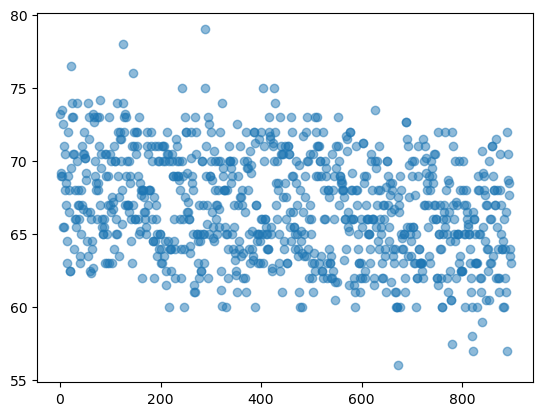

In [8]:
#Plot data
dummy = np. arange(0,len(d['height']),1) #Create dummy variable to plot data
plt.scatter(dummy,d['height'],alpha=0.5) #Scatter plot of midparent vs child height

In [9]:
# Compute summary statistics with python
a = np.random.normal(0,1,1000) #Generate a random array
b = np.random.normal(0,1,1000) #Generate another random array
mean = np.mean(a) #Calculate mean
std = np.std(a) #Calculate standard deviation
corr, pval = pearsonr(a,b) #Calculate correlation and p-value
print("Mean:", mean, "Standard deviation:", std, "Correlation:", corr, "P-value:", pval) #Print results

Mean: -0.0048181408116557125 Standard deviation: 0.959270928079509 Correlation: -0.010477099180291688 P-value: 0.7407127199581036


In [13]:
# Make linear regresions with python
x = np.linspace(-3,3,100) #Create x values
y = 2*x + 1 + np.random.normal(0,1,100) #Create y values with noise
slope, intercept, r_value, p_value, std_err = linregress(x,y) #Calculate linear regression
print("Slope:", slope, "Intercept:", intercept, "R-squared:", r_value**2, "P-value:", p_value)

Slope: 1.9680075698797372 Intercept: 1.1072827175767916 R-squared: 0.9255733237896804 P-value: 4.3288027093488907e-57


In [12]:
# Compute probabilities using Numpy
a = np.random.normal(0,1,1000) #Generate a random array
N_events = np.sum(a>0.2) #Count number of events greater than 0.2
prob = N_events/len(a) #Calculate probability
print("Probability of event greater than 0.2=", prob) #Print probability

Probability of event greater than 0.2= 0.417
